In [31]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import xarray as xr
import scipy as sp
import MSMUtilities as mu
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/EmpiricalData/PSD'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def _statesPSD(session,regs=None,when='sleep.*#0',bin=0.05,nperseg=8):

    R = fma.regions.regions(session,phases=when,states=['sws','rem'])
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    fr = R.firingRate(regs=regs,window=bin)

    states = ['sws','rem','other']
    psd = []
    for i, state in enumerate(states):
        fr_state = fma.general.restrict(fr,R.eventIntervals(state))
        freq, p = sp.signal.welch(fr_state[:,1:],fs=1/bin,nperseg=2**nperseg,axis=0)
        psd.append(p)
    # normalize to pdf(power)
    psd = np.array(psd)
    psd = psd / np.trapezoid(psd,freq,axis=1)[:,None,:]

    psd = xr.DataArray(psd,dims=['state','f','reg'],coords={'state': states, 'f': freq, 'reg': regs, 'rat': int(R.rat)})

    return psd


In [3]:
session = fma.data.readBatchFile(batch_file)[0][8]
print(session)
psd = _statesPSD(session,bin=0.05,nperseg=10)

/mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml


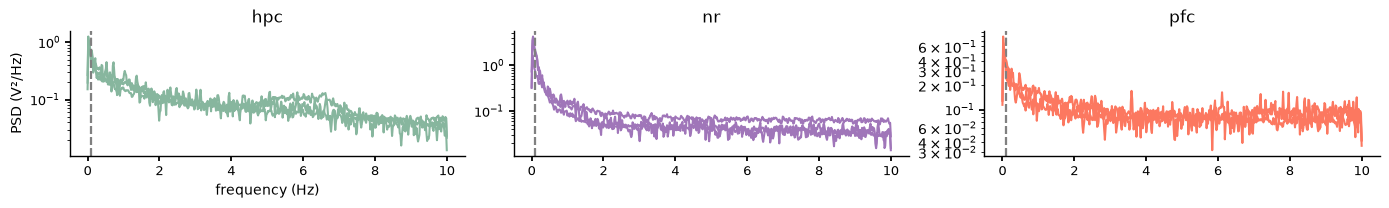

In [4]:
fig, ax = fma.plotting.makeFigure(size=(35,5),n=(1,3))
for i, reg in enumerate(psd.reg.values):
    for j, state in enumerate(psd.state.values):
        ax[j].axvline(0.1,ls='--',color='gray')
        ax[i].semilogy(psd.f,psd.sel(reg=reg,state=state),color=mu.paperColors(reg))
        #ax[i].set_xlim([0,1])
        ax[i].set(title=reg)
ax[0].set(xlabel='frequency (Hz)',ylabel='PSD (V²/Hz)');

run batch

In [23]:
bin = 0.05
psd = fma.data.runBatch(batch_file,_statesPSD,kwargs={'regs': ['hpc','nr','pfc'],'bin': bin, 'nperseg': 8},parallel=True)
psd_cat = xr.concat([d for d in psd if d is not None],dim='rat',coords='different',join='outer')
psd_avg = psd_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-07-17 15:54:57.428913 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.xml (42)
/mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.sws not found.
Traceback:
Batch completed with 5 errors, 2026-07-17 15:55:08

/tmp/ipykernel_1500201/3882534495.py:3: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  psd_cat = xr.concat([d for d in psd if d is not None],dim='rat',coords='different',join='outer')


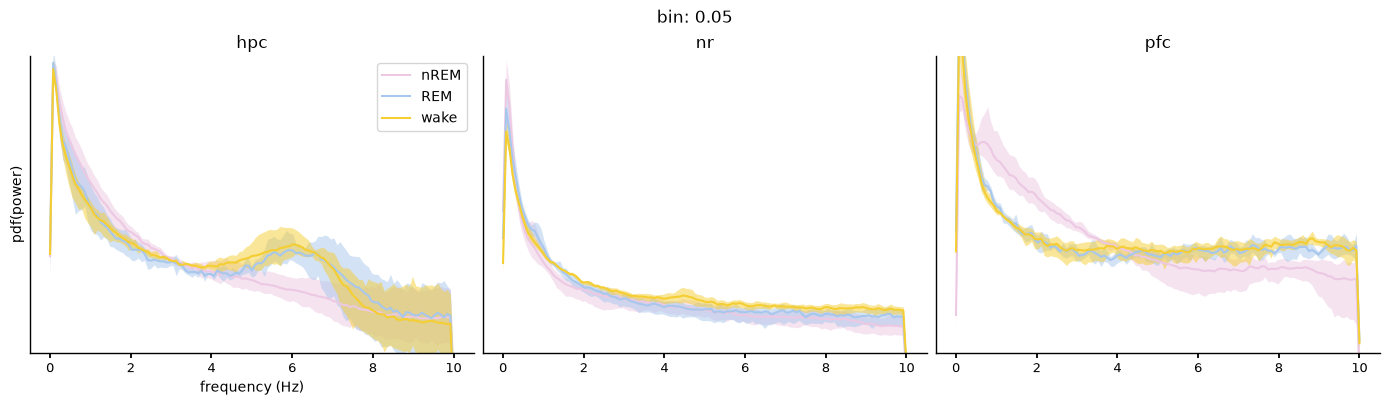

In [36]:
fig, ax = fma.plotting.makeFigure(f'bin: {bin}',size=(35,10),n=(1,len(psd_avg.reg.values)))
states = psd_avg.state.values
labels = ['nREM','REM','wake']
for i, reg in enumerate(psd_avg.reg.values):
    for j, state in enumerate(states):
        fma.plotting.semPlot(psd_avg.f,psd_avg.sel(reg=reg,state=state),color=mu.paperColors(state),label=labels[j],ax=ax[i])
        ax[i].set(title=reg,yscale='log',ylim=[0.04,ax[i].get_ylim()[1]],yticks=[])
        ax[i].minorticks_off()
ax[0].legend()
ax[0].set(xlabel='frequency (Hz)',ylabel='pdf(power)')
do_save and fma.plotting.saveFigure(fig,froot / f'PSD_bin{bin}',format=['png','svg'])

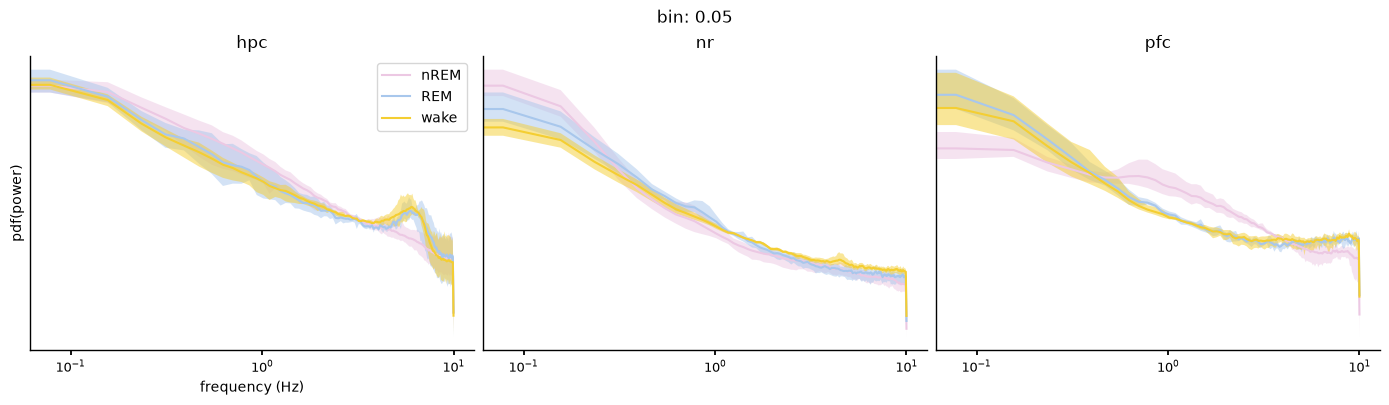

In [38]:
fig, ax = fma.plotting.makeFigure(f'bin: {bin}',size=(35,10),n=(1,len(psd_avg.reg.values)))
states = psd_avg.state.values
labels = ['nREM','REM','wake']
for i, reg in enumerate(psd_avg.reg.values):
    for j, state in enumerate(states):
        fma.plotting.semPlot(psd_avg.f,psd_avg.sel(reg=reg,state=state),color=mu.paperColors(state),label=labels[j],ax=ax[i])
        ax[i].set(title=reg,xscale='log',yscale='log',yticks=[])
        ax[i].minorticks_off()
ax[0].legend()
ax[0].set(xlabel='frequency (Hz)',ylabel='pdf(power)')
do_save and fma.plotting.saveFigure(fig,froot / f'PSD_loglog_bin{bin}',format=['png','svg'])